In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from MODELS.xgboostModel import *
from MODELS.ngboostModel import *
from PRODUCTION.pipeline import *
from FEATURES.features import *

In [2]:
pd.set_option('display.max_columns', None)

# s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

for df in [s20,s21,s22,s23,s24,s25,s26]:
    df['PTS_ROLLING_10_X_OPP_DEF_RATING'] = df['PTS_ROLLING_AVG_10'] * df['OPP_DEF_RATING_AVG_TO_DATE']
    df['FGA_ROLLING_10_X_OPP_DEF_RATING'] = df['FGA_ROLLING_AVG_10'] * df['OPP_DEF_RATING_AVG_TO_DATE']
    df['OFF_RATING_ROLLING_10_X_OPP_DEF_RATING'] = df['E_OFF_RATING_ROLLING_AVG_10'] * df['OPP_DEF_RATING_AVG_TO_DATE']
    df['FG3A_ROLLING_10_X_OPP_DEF_RATING'] = df['FG3A_ROLLING_AVG_10'] * df['OPP_DEF_RATING_AVG_TO_DATE']
    df['USAGE_X_OPP_DEF_RATING'] = df['USG_PCT_ROLLING_AVG_10'] * df['OPP_DEF_RATING_AVG_TO_DATE']

train_df = pd.concat([s20,s21,s22,s23,s24,s25])
train_df = train_df[(train_df['MIN'] >= 10)]
train_df = train_df.dropna(subset=['PTS_ROLLING_AVG_3'])

val_df = s26
val_df = val_df[(val_df['MIN'] >= 10)]
val_df = val_df.dropna(subset=['PTS_ROLLING_AVG_3'])

print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")

val_df.tail(5)

Train set: 125159 samples
Val set: 4490 samples


,Unnamed: 0,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK_x,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,matchupFieldGoalsPercentage,matchupThreePointersPercentage,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLK_y,BLKA,PF,PFD,TEAM_SEASON_ID,TEAM_NAME,TEAM_GAME_DATE,TEAM_MATCHUP,TEAM_WL,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,VIDEO_AVAILABLE,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,STARTING,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_3,FGA_ROLLING_AVG_3,FGM_ROLLING_AVG_3,FG3A_ROLLING_AVG_3,FG3M_ROLLING_AVG_3,FTA_ROLLING_AVG_3,FTM_ROLLING_AVG_3,USG_PCT_ROLLING_AVG_3,MIN_ROLLING_AVG_3,POSS_ROLLING_AVG_3,PLUS_MINUS_ROLLING_AVG_3,E_OFF_RATING_ROLLING_AVG_3,NET_RATING_ROLLING_AVG_3,EFG_PCT_ROLLING_AVG_3,UFGA_ROLLING_AVG_3,UFGM_ROLLING_AVG_3,PF_ROLLING_AVG_3,OREB_ROLLING_AVG_3,PTS_OFF_TOV_ROLLING_AVG_3,PTS_2ND_CHANCE_ROLLING_AVG_3,PTS_FB_ROLLING_AVG_3,PTS_PAINT_ROLLING_AVG_3,PTS_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,POSS_ROLLING_AVG_5,PLUS_MINUS_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,UFGA_ROLLING_AVG_5,UFGM_ROLLING_AVG_5,PF_ROLLING_AVG_5,OREB_ROLLING_AVG_5,PTS_OFF_TOV_ROLLING_AVG_5,PTS_2ND_CHANCE_ROLLING_AVG_5,PTS_FB_ROLLING_AVG_5,PTS_PAINT_ROLLING_AVG_5,PTS_ROLLING_AVG_7,FGA_ROLLING_AVG_7,FGM_ROLLING_AVG_7,FG3A_ROLLING_AVG_7,FG3M_ROLLING_AVG_7,FTA_ROLLING_AVG_7,FTM_ROLLING_AVG_7,USG_PCT_ROLLING_AVG_7,MIN_ROLLING_AVG_7,POSS_ROLLING_AVG_7,PLUS_MINUS_ROLLING_AVG_7,E_OFF_RATING_ROLLING_AVG_7,NET_RATING_ROLLING_AVG_7,EFG_PCT_ROLLING_AVG_7,UFGA_ROLLING_AVG_7,UFGM_ROLLING_AVG_7,PF_ROLLING_AVG_7,OREB_ROLLING_AVG_7,PTS_OFF_TOV_ROLLING_AVG_7,PTS_2ND_CHANCE_ROLLING_AVG_7,PTS_FB_ROLLING_AVG_7,PTS_PAINT_ROLLING_AVG_7,PTS_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,POSS_ROLLING_AVG_10,PLUS_MINUS_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,UFGA_ROLLING_AVG_10,UFGM_ROLLING_AVG_10,PF_ROLLING_AVG_10,OREB_ROLLING_AVG_10,PTS_OFF_TOV_ROLLING_AVG_10,PTS_2ND_CHANCE_ROLLING_AVG_10,PTS_FB_ROLLING_AVG_10,PTS_PAINT_ROLLING_AVG_10,PTS_ROLLING_AVG_20,FGA_ROLLING_AVG_20,FGM_ROLLING_AVG_20,FG3A_ROLLING_AVG_20,FG3M_ROLLING_AVG_20,FTA_ROLLING_AVG_20,FTM_ROLLING_AVG_20,USG_PCT_ROLLING_AVG_20,MIN_ROLLING_AVG_20,POSS_ROLLING_

In [3]:
featuresV4 = [
    # ===== CORE CONTEXT (1) =====
    'STARTING',
    'USUAL_STARTERS_OUT',
    'STAR_SAT_OUT',
    'PLAYER_DAYS_REST',
    
    # ===== ROLLING AVERAGES =====
    'PTS_ROLLING_AVG_3',
    'PTS_ROLLING_AVG_7',
    'PTS_ROLLING_AVG_20',
    'FGA_ROLLING_AVG_3',
    'FGA_ROLLING_AVG_5',
    'FGA_ROLLING_AVG_7',
    'FGA_ROLLING_AVG_20',
    'FTM_ROLLING_AVG_5',
    'FTM_ROLLING_AVG_10',
    'FTM_ROLLING_AVG_20',
    'FTA_ROLLING_AVG_3',
    'FTA_ROLLING_AVG_5',
    'FTA_ROLLING_AVG_7',
    'MIN_ROLLING_AVG_3',
    'USG_PCT_ROLLING_AVG_3',
    'UFGA_ROLLING_AVG_10',
    'UFGA_ROLLING_AVG_20',
    'PTS_PAINT_ROLLING_AVG_3',
    'POSS_ROLLING_AVG_3',
    
    # ===== INTERACTIONS (5) =====
    'PTS_PER_MIN_X_USG',
    'USAGE_X_MINUTES',
    'USAGE_X_PTS',
    'FGA_PER_MIN',
    'FG3A_PER_MIN',
    'FG3A_EXPECTATION_TEAM_STAR',
    'FG3_PCT_AVG_TO_DATE',
    
    # ===== STAR DYNAMICS (7) =====
    'PTS_BOOST_STAR_OUT',
    'FGA_BOOST_STAR_OUT',
    'FGM_BOOST_STAR_OUT',
    'FTM_BOOST_STAR_OUT',
    'FG3M_BOOST_STAR_OUT',
    'TS_PCT_DELTA_STAR_OUT',
    'GAMES_WITH_STAR',
    'GAMES_WITHOUT_STAR',
    
    # ===== SCORER TIERS (3) =====
    'IS_LOW_SCORER',
    'LOW_SCORER_X_MIN',
    'LOW_SCORER_X_PTS',
    'MEDIUM_SCORER_X_PTS',
    
    # ===== TEAM CONTEXT (6) =====
    'TEAM_PTS_ROLLING_AVG_3',
    'TEAM_AST_ROLLING_AVG_3',
    'TEAM_DEF_RATING_ROLLING_AVG_3',
    'TEAM_FG3M_ROLLING_AVG_3',
    'TEAM_FTM_ROLLING_AVG_3',
    'TEAM_GUARD_DEF_RATING',
    
    # ===== OPPONENT INTERACTIONS (3) =====
    'FGA_ROLLING_10_X_OPP_DEF_RATING',
    'PTS_ROLLING_10_X_OPP_DEF_RATING',
    'USAGE_X_OPP_DEF_RATING',
    'USAGE_X_FGA_X_OPP_DEF_RATING',
    'OPP_GUARD_DEF_RATING',
    'OPP_FORWARD_DEF_RATING',
    
    # ===== GAME CONTEXT (4) =====
    'EXPECTED_PACE_X_PTS',
    'EXPECTED_PACE_X_USG',
]
print(f"FeaturesV3 count: {len(featuresV4)}")  

FeaturesV3 count: 56


In [ ]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('GUARD')
# features = columns[guardIDX + 1:]
# numeric_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()
# features = [col for col in features if col in numeric_columns]
# newFeatures = features

In [ ]:
# from MODELS.xgboostModel import *

# X_selected, selected_features, importance_df = select_features_ngboost(
#     X=train_df[newFeatures],
#     y=train_df['PTS'],
#     top_n=60,     # Select more features
#     n_runs=4,    # More runs for stability
#     validate_both_distributions=True
# )

Selecting features for NGBoost (mean + variance)...
Analyzing variance modeling importance...

Selected 60 features

Top 10 features (combined importance):
                feature  mean_importance  variance_importance  combined_importance
 TEAM_PTS_ROLLING_AVG_3         0.074462             0.001811             0.052667
        USAGE_X_MINUTES         0.061122             0.000000             0.042786
      FGA_ROLLING_AVG_3         0.059702             0.002233             0.042461
USAGE_X_FGA_X_TEAM_PACE         0.000835             0.119163             0.036333
   OPP_GUARD_DEF_RATING         0.046359             0.001359             0.032859
     PTS_ROLLING_AVG_20         0.038173             0.000144             0.026764
     FGA_ROLLING_AVG_10         0.001628             0.082729             0.025958
     FGA_ROLLING_AVG_20         0.011260             0.051783             0.023417
      MIN_ROLLING_AVG_3         0.030021             0.001073             0.021337
     PTS_BOOST

# NGBOOST MODEL

### Remove correlated features

In [4]:
# from MODELS.xgboostModel import *
# corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

final_features = remove_highly_correlated_features(train_df, featuresV4, threshold=0.995)


SUMMARY:
Original features: 56
Missing from dataframe: 0
Removed (high correlation): 0
Final features: 56


### NGBOOST MODEL

SPLIT NGBOOST

In [5]:

mean_model, variance_model, cal_factor = fit_ngboost_split(
train_df,
val_df,
final_features,
target_col='PTS',
distribution=Normal,
player_col='PLAYER_ID',
recent_n=20,
recent_weight=2.0,
variance_recent_weight=1.0,
variance_lr=0.01,  
variance_max_depth=7,  
variance_n_estimators=1000,
variance_calibration_factor=4.4)


Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.


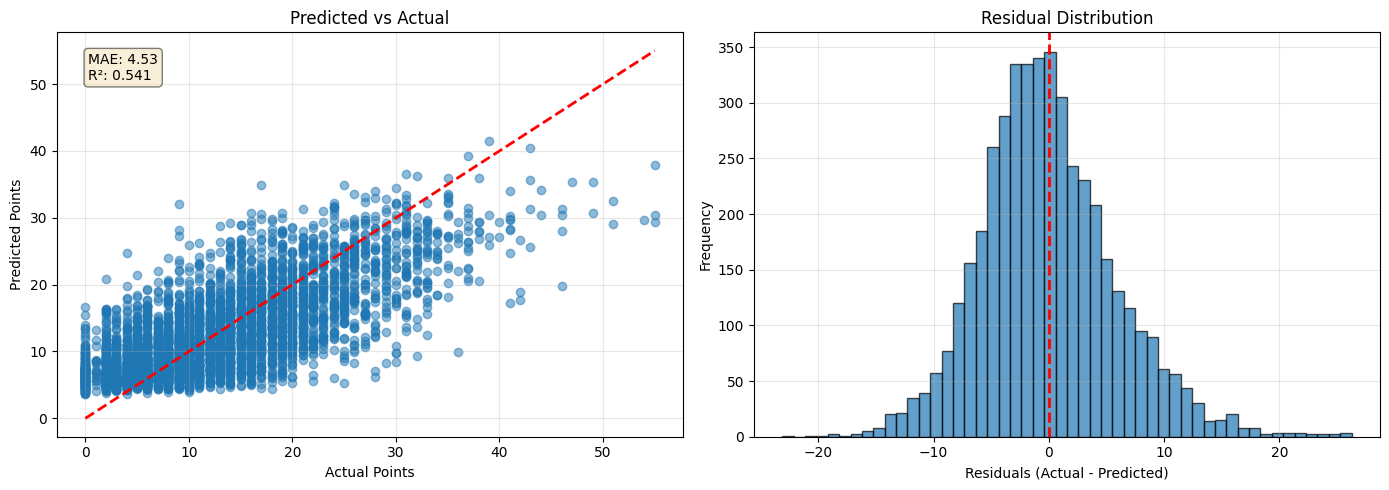

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

preds_dist = mean_model.pred_dist(val_df[final_features])
y_pred_mean = preds_dist.loc
y_pred_std = preds_dist.scale
y_true = val_df['PTS'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_true, y_pred_mean, alpha=0.5)
axes[0].plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')
axes[0].set_title('Predicted vs Actual')
axes[0].grid(True, alpha=0.3)

mae = mean_absolute_error(y_true, y_pred_mean)
r2 = r2_score(y_true, y_pred_mean)
axes[0].text(0.05, 0.95, f'MAE: {mae:.2f}\nR²: {r2:.3f}', 
             transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

residuals = y_true - y_pred_mean
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
mean_importance_raw = mean_model.feature_importances_  
var_importance_raw = variance_model.feature_importances_    

# Average across the 2 distributions
mean_importance = mean_importance_raw.mean(axis=0)  
var_importance = var_importance_raw.mean(axis=0)    

# NOW create the DataFrame
feature_importance_df = pd.DataFrame({
    'feature': final_features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('mean_model', ascending=False)

# Display top features
print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'mean_model']].head(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)
                        feature  mean_model
             PTS_ROLLING_AVG_20    0.079666
                USAGE_X_MINUTES    0.059232
                    USAGE_X_PTS    0.053659
             FGA_ROLLING_AVG_20    0.048382
FGA_ROLLING_10_X_OPP_DEF_RATING    0.045085
           OPP_GUARD_DEF_RATING    0.032313
         TEAM_PTS_ROLLING_AVG_3    0.031829
            EXPECTED_PACE_X_PTS    0.031198
                   FG3A_PER_MIN    0.025631
          TEAM_GUARD_DEF_RATING    0.024339
              FGA_ROLLING_AVG_7    0.023998
  TEAM_DEF_RATING_ROLLING_AVG_3    0.023032
              FGA_ROLLING_AVG_3    0.022749
PTS_ROLLING_10_X_OPP_DEF_RATING    0.021107
         OPP_FORWARD_DEF_RATING    0.020916
         TEAM_AST_ROLLING_AVG_3    0.020181
        TEAM_FG3M_ROLLING_AVG_3    0.018126
              PTS_PER_MIN_X_USG    0.017852
            MEDIUM_SCORER_X_PTS    0.017826
   USAGE_X_FGA_X_OPP_DEF_RATING    0.017466


In [8]:
feature_importance_df = pd.DataFrame({
    'feature': final_features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('var_model', ascending=False)


print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'var_model']].head(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)
                        feature  var_model
FGA_ROLLING_10_X_OPP_DEF_RATING   0.054290
   USAGE_X_FGA_X_OPP_DEF_RATING   0.040552
           OPP_GUARD_DEF_RATING   0.037992
         OPP_FORWARD_DEF_RATING   0.037219
             FGA_ROLLING_AVG_20   0.036970
                   FG3A_PER_MIN   0.033955
         TEAM_PTS_ROLLING_AVG_3   0.031610
          TEAM_GUARD_DEF_RATING   0.030914
  TEAM_DEF_RATING_ROLLING_AVG_3   0.030907
            UFGA_ROLLING_AVG_20   0.029190
                    FGA_PER_MIN   0.024930
         TEAM_FTM_ROLLING_AVG_3   0.023067
         USAGE_X_OPP_DEF_RATING   0.022974
              FGA_ROLLING_AVG_5   0.022875
               LOW_SCORER_X_MIN   0.022517
              MIN_ROLLING_AVG_3   0.021411
            EXPECTED_PACE_X_USG   0.021191
              PTS_PER_MIN_X_USG   0.020709
         TEAM_AST_ROLLING_AVG_3   0.019848
        TEAM_FG3M_ROLLING_AVG_3   0.019682


In [9]:
validate_production_model(mean_model, variance_model, val_df, final_features, 'PTS', cal_factor)

=== CALIBRATION CHECK ===
Standardized residuals mean: 0.002 (should be ~0)
Standardized residuals std: 0.959 (should be ~1)
Q25: Predicted=8.4, Actual=6.0
Q50: Predicted=12.5, Actual=11.0
Q75: Predicted=16.5, Actual=18.0

MAE: 4.52
90% CI: Coverage=91.78%, Expected=90.00%
95% CI: Coverage=95.90%, Expected=95.00%
99% CI: Coverage=98.91%, Expected=99.00%


array([-0.66934481,  1.05710248,  0.51657824, ...,  2.22634023,
       -0.64622402, -0.47523049], shape=(4490,))

In [10]:
import joblib

# Save NGBoost split models (mean, variance, calibration factor)
joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_PRODUCTIONv2.pkl')
joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_PRODUCTIONv2.pkl')
joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_PRODUCTIONv2.pkl')

joblib.dump(final_features, 'SAVED_MODELS/feature_listv2.pkl')

print("="*80)
print("Models saved successfully!")
print("="*80)
print("✓ Mean model")
print("✓ Variance model")
print("✓ Calibration factor")
print("✓ Feature list")

Models saved successfully!
✓ Mean model
✓ Variance model
✓ Calibration factor
✓ Feature list


In [24]:
# import joblib

# # Save NGBoost split models (mean, variance, calibration factor)
# joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_BACKTEST.pkl')
# joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_BACKTEST.pkl')
# joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_BACKTEST.pkl')

# joblib.dump(features, 'SAVED_MODELS/feature_list.pkl')

# print("="*80)
# print("Models saved successfully!")
# print("="*80)
# print("✓ Mean model")
# print("✓ Variance model")
# print("✓ Calibration factor")
# print("✓ Feature list")

Models saved successfully!
✓ Mean model
✓ Variance model
✓ Calibration factor
✓ Feature list


MODEL PERFORMANCE BY PERCENTILE BIN
    Bin  Count  True_Mean  Pred_Mean      MAE      RMSE         R2  Mean_Error  Overall_Rank
Q20-Q30    462   6.417749   8.889372 2.962513  4.127795 -69.050413    2.471623           1.0
Q30-Q40    488   8.504098   9.929959 3.047440  4.264235 -71.739693    1.425861           2.0
Q40-Q50    409  10.459658  10.889462 3.257766  4.158492 -68.625481    0.429805           3.0
Q10-Q20    438   4.511416   8.222617 3.730461  4.854371 -93.308827    3.711201           4.5
Q50-Q60    367  12.457766  11.894861 3.338517  4.165181 -68.893610   -0.562905           4.5
Q60-Q70    482  14.931535  13.933855 4.435661  5.444857 -43.551867   -0.997680           6.0
Q70-Q80    386  17.945596  15.828408 4.771049  5.914147 -54.365014   -2.117188           7.0
   <Q10    585   1.736752   7.383995 5.647243  6.311908 -27.030831    5.647243           8.0
Q80-Q90    482  22.089212  17.933290 5.685865  6.788606 -14.564473   -4.155922           9.0
   >Q90    391  31.409207  23.6165

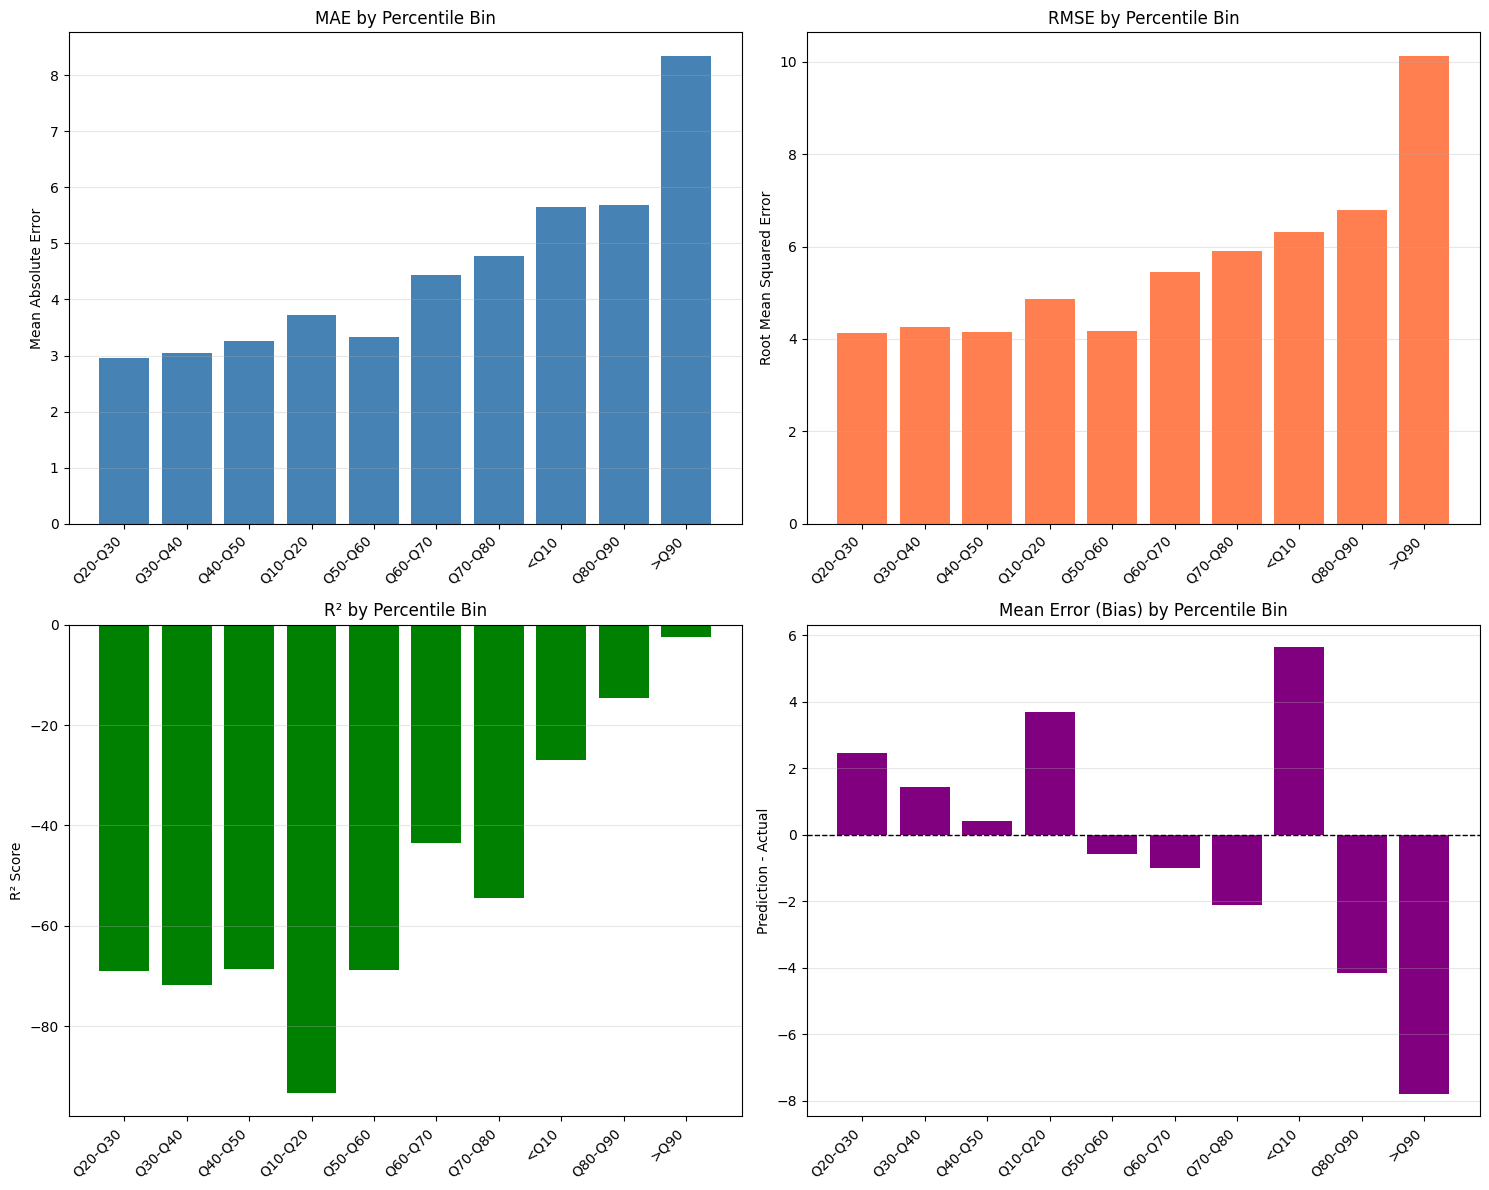

,Bin,Count,True_Mean,True_Median,Pred_Mean,Pred_Median,MAE,RMSE,R2,Mean_Error,Median_Error,MAPE,MAE_Rank,RMSE_Rank,R2_Rank,Overall_Score,Overall_Rank
2,Q20-Q30,462,6.417749,6.0,8.889372,8.158075,2.962513,4.127795,-69.050413,2.471623,1.749143,4.644907e+01,1.0,1.0,8.0,-6.0,1.0
3,Q30-Q40,488,8.504098,9.0,9.929959,9.096189,3.047440,4.264235,-71.739693,1.425861,0.664135,3.583278e+01,2.0,4.0,9.0,-3.0,2.0
4,Q40-Q50,409,10.459658,10.0,10.889462,10.169305,3.257766,4.158492,-68.625481,0.429805,-0.145371,3.113145e+01,3.0,2.0,6.0,-1.0,3.0
1,Q10-Q20,438,4.511416,5.0,8.222617,7.388406,3.730461,4.854371,-93.308827,3.711201,2.904766,8.412933e+01,5.0,5.0,10.0,0.0,4.5
5,Q50-Q60,367,12.457766,12.0,11.894861,11.128394,3.338517,4.165181,-68.893610,-0.562905,-1.194480,2.683140e+01,4.0,3.0,7.0,0.0,4.5
6,Q60-Q70,482,14.931535,15.0,13.933855,13.385621,4.435661,5.444857,-43.551867,-0.997680,-1.293781,2.962644e+01,6.0,6.0,4.0,8.0,6.0
7,Q70-Q80,386,17.945596,18.0,15.828408,15.532325,4.771049,5.914147,-54.365014,-2.117188,-2.463722,2.656122e+01,7.0,7.0,5.0,9.0,7.0
0,<Q10,585,1.736752,2.0,7.383995,6.707764,5.647243,6.311908,-27.030831,5.647243,5.157601,1.955416e+08,8.0,8.0,3.0,13.0,8.0
8,Q80-Q90,482,22.089212,22.0,17.933290,17.416203,5.685865,6.788606,-14.564473,-4.155922,-4.521046,2.578772e+01,9.0,9.0,2.0,16.0,9.0
9,>Q90,391,31.409207,30.0,23.616510,24.395142,8.346628,10.130042,-2.505915,-7.792697,-7.714001,2.610359e+01,10.0,10.0,1.0,19.0,10.0


In [12]:
def analyze_percentile_bins(val_df, model, features, target_col='PTS', 
                           percentiles=[10, 20, 30, 40, 50, 60, 70, 80, 90],
                           calibration_factor=1.25):
    """
    Analyze model performance across percentile bins (Q10-Q90)
    
    Args:
        val_df: Validation dataframe
        model: Trained model (tuple of mean_model, variance_model) or single model
        features: List of feature names
        target_col: Target column name (default 'PTS')
        percentiles: List of percentiles to create bins
        calibration_factor: Calibration factor for variance model
    
    Returns:
        DataFrame with performance metrics per bin
    """
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    
    # Prepare data
    df = val_df.copy()
    X = df[features].replace([np.inf, -np.inf], np.nan).fillna(df[features].median())
    y_true = df[target_col].values
    
    # Make predictions
    if isinstance(model, tuple):
        mean_model, variance_model = model
        from MODELS.ngboostModel import predict_mean_variance_split
        y_pred, _ = predict_mean_variance_split(mean_model, variance_model, X, features, calibration_factor)
        y_pred = y_pred.values if hasattr(y_pred, 'values') else y_pred
    else:
        y_pred = model.predict(X)
        if hasattr(y_pred, 'values'):
            y_pred = y_pred.values
    
    # Calculate actual percentiles from true values
    percentile_values = np.percentile(y_true, percentiles)
    
    # Create bins
    bins = []
    bin_labels = []
    for i in range(len(percentiles) - 1):
        lower = percentile_values[i]
        upper = percentile_values[i + 1]
        bins.append((lower, upper))
        bin_labels.append(f'Q{percentiles[i]}-Q{percentiles[i+1]}')
    
    # Add first and last bins
    bins.insert(0, (-np.inf, percentile_values[0]))
    bin_labels.insert(0, f'<Q{percentiles[0]}')
    bins.append((percentile_values[-1], np.inf))
    bin_labels.append(f'>Q{percentiles[-1]}')
    
    # Assign each sample to a bin
    df['bin'] = pd.cut(y_true, bins=[-np.inf] + list(percentile_values) + [np.inf], 
                       labels=bin_labels, include_lowest=True)
    
    # Calculate metrics for each bin
    results = []
    for bin_label in bin_labels:
        mask = df['bin'] == bin_label
        if mask.sum() == 0:
            continue
            
        y_true_bin = y_true[mask]
        y_pred_bin = y_pred[mask]
        
        mae = mean_absolute_error(y_true_bin, y_pred_bin)
        rmse = np.sqrt(mean_squared_error(y_true_bin, y_pred_bin))
        r2 = r2_score(y_true_bin, y_pred_bin)
        mean_error = np.mean(y_pred_bin - y_true_bin)  # Bias
        median_error = np.median(y_pred_bin - y_true_bin)
        mape = np.mean(np.abs((y_true_bin - y_pred_bin) / (y_true_bin + 1e-6))) * 100
        
        results.append({
            'Bin': bin_label,
            'Count': len(y_true_bin),
            'True_Mean': np.mean(y_true_bin),
            'True_Median': np.median(y_true_bin),
            'Pred_Mean': np.mean(y_pred_bin),
            'Pred_Median': np.median(y_pred_bin),
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Mean_Error': mean_error,
            'Median_Error': median_error,
            'MAPE': mape,
            'MAE_Rank': 0,  # Will fill later
            'RMSE_Rank': 0,
            'R2_Rank': 0
        })
    
    results_df = pd.DataFrame(results)
    
    # Rank performance (lower MAE/RMSE is better, higher R2 is better)
    results_df['MAE_Rank'] = results_df['MAE'].rank(ascending=True)
    results_df['RMSE_Rank'] = results_df['RMSE'].rank(ascending=True)
    results_df['R2_Rank'] = results_df['R2'].rank(ascending=False)
    
    # Overall score (lower is better)
    results_df['Overall_Score'] = (results_df['MAE_Rank'] + results_df['RMSE_Rank'] - results_df['R2_Rank'])
    results_df['Overall_Rank'] = results_df['Overall_Score'].rank(ascending=True)
    
    return results_df.sort_values('Overall_Score')


# Run the analysis
bin_analysis = analyze_percentile_bins(
    val_df, 
    mean_model,  # Your trained model
    final_features,
    target_col='PTS',
    percentiles=[10, 20, 30, 40, 50, 60, 70, 80, 90]
)

print("="*80)
print("MODEL PERFORMANCE BY PERCENTILE BIN")
print("="*80)
print(bin_analysis[['Bin', 'Count', 'True_Mean', 'Pred_Mean', 'MAE', 'RMSE', 'R2', 'Mean_Error', 'Overall_Rank']].to_string(index=False))

print("\n" + "="*80)
print("BEST PERFORMING BINS (Lowest Overall Score)")
print("="*80)
print(bin_analysis.nsmallest(3, 'Overall_Score')[['Bin', 'Count', 'MAE', 'RMSE', 'R2', 'Mean_Error']].to_string(index=False))

print("\n" + "="*80)
print("WORST PERFORMING BINS (Highest Overall Score)")
print("="*80)
print(bin_analysis.nlargest(3, 'Overall_Score')[['Bin', 'Count', 'MAE', 'RMSE', 'R2', 'Mean_Error']].to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# MAE by bin
axes[0, 0].bar(range(len(bin_analysis)), bin_analysis['MAE'], color='steelblue')
axes[0, 0].set_xticks(range(len(bin_analysis)))
axes[0, 0].set_xticklabels(bin_analysis['Bin'], rotation=45, ha='right')
axes[0, 0].set_title('MAE by Percentile Bin')
axes[0, 0].set_ylabel('Mean Absolute Error')
axes[0, 0].grid(axis='y', alpha=0.3)

# RMSE by bin
axes[0, 1].bar(range(len(bin_analysis)), bin_analysis['RMSE'], color='coral')
axes[0, 1].set_xticks(range(len(bin_analysis)))
axes[0, 1].set_xticklabels(bin_analysis['Bin'], rotation=45, ha='right')
axes[0, 1].set_title('RMSE by Percentile Bin')
axes[0, 1].set_ylabel('Root Mean Squared Error')
axes[0, 1].grid(axis='y', alpha=0.3)

# R² by bin
axes[1, 0].bar(range(len(bin_analysis)), bin_analysis['R2'], color='green')
axes[1, 0].set_xticks(range(len(bin_analysis)))
axes[1, 0].set_xticklabels(bin_analysis['Bin'], rotation=45, ha='right')
axes[1, 0].set_title('R² by Percentile Bin')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].grid(axis='y', alpha=0.3)

# Mean Error (Bias) by bin
axes[1, 1].bar(range(len(bin_analysis)), bin_analysis['Mean_Error'], color='purple')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xticks(range(len(bin_analysis)))
axes[1, 1].set_xticklabels(bin_analysis['Bin'], rotation=45, ha='right')
axes[1, 1].set_title('Mean Error (Bias) by Percentile Bin')
axes[1, 1].set_ylabel('Prediction - Actual')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Show the full results
bin_analysis